In [3]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

import numpy as np
import scipy.stats as stats

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
url = "winequality-white.csv"
data = pd.read_csv(url, sep=";")

In [13]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [17]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [18]:
for i in data.keys():
    print(f'{i} has {len(np.unique(data[i]))} unique values')

fixed acidity has 68 unique values
volatile acidity has 125 unique values
citric acid has 87 unique values
residual sugar has 310 unique values
chlorides has 160 unique values
free sulfur dioxide has 132 unique values
total sulfur dioxide has 251 unique values
density has 890 unique values
pH has 103 unique values
sulphates has 79 unique values
alcohol has 103 unique values
quality has 7 unique values


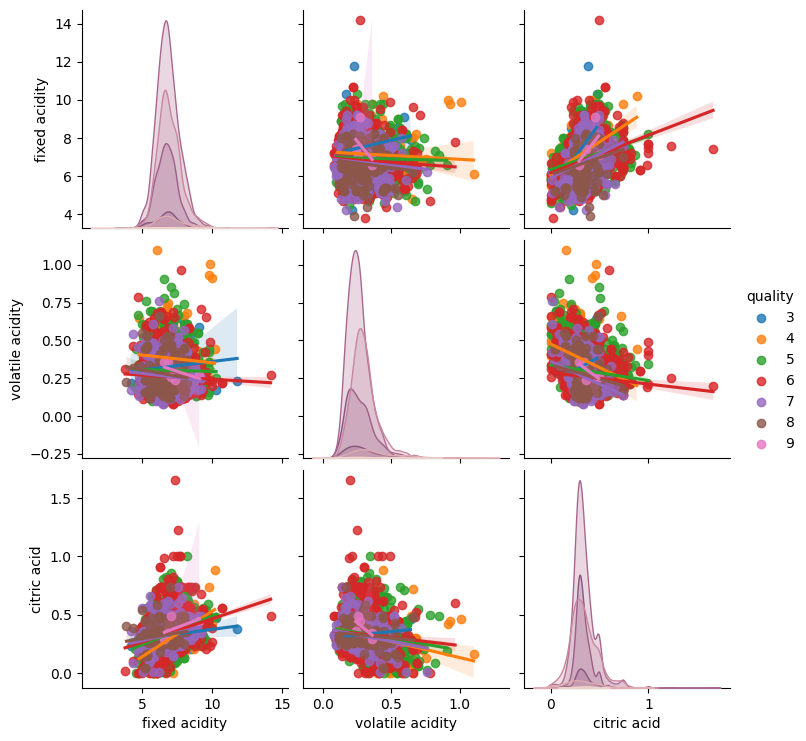

In [19]:
cols2plot = ['fixed acidity', 'volatile acidity', 'citric acid', 'quality']
sns.pairplot(data[cols2plot], kind='reg', hue='quality')
plt.show()

/tmp/ipykernel_23260/2919453339.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


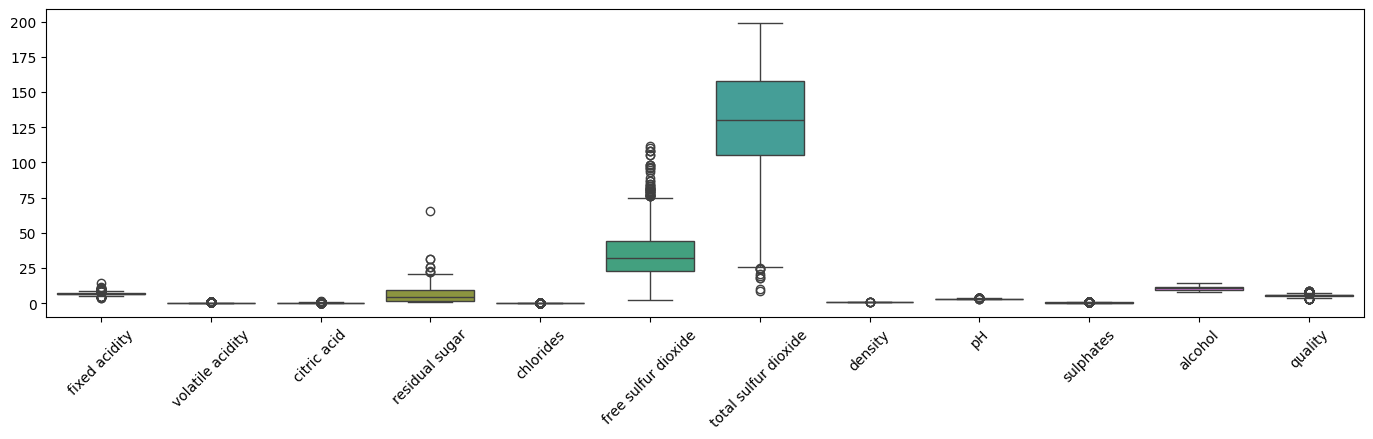

In [22]:
data = data[data['total sulfur dioxide'] <200]

fig, ax = plt.subplots(1, figsize=(17,4))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

In [23]:
cols2zscore = data.keys()
cols2zscore = cols2zscore.drop('quality')

for col in cols2zscore:
    meanval = np.mean(data[col])
    stdev = np.std(data[col], ddof=1)
    data[col] = (data[col]-meanval) / stdev

data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4.489000e+03,4.489000e+03,4.489000e+03,4.489000e+03,4.489000e+03,4.489000e+03,4.489000e+03,4.489000e+03,4.489000e+03,4.489000e+03,4.489000e+03,4489.000000
mean,-7.597695e-17,5.935699e-16,-2.532565e-17,-4.115418e-17,3.608905e-16,9.497118e-17,2.532565e-16,1.171311e-14,-1.988063e-15,3.545591e-16,6.331412e-17,5.911562
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.886607
min,-3.565331e+00,-1.951696e+00,-2.771344e+00,-1.091138e+00,-1.720957e+00,-2.038347e+00,-3.451430e+00,-2.265644e+00,-3.080185e+00,-2.307892e+00,-2.110347e+00,3.000000
25%,-6.351384e-01,-6.539825e-01,-5.189335e-01,-8.918694e-01,-4.843794e-01,-6.866897e-01,-7.318412e-01,-7.405023e-01,-7.167271e-01,-7.532769e-01,-8.939520e-01,5.000000
50%,-4.909982e-02,-1.548619e-01,-1.018205e-01,-2.641738e-01,-1.514546e-01,-1.074082e-01,-2.361491e-02,-1.290871e-01,-6.021110e-02,-1.487045e-01,-8.302230e-02,6.000000
75%,5.369387e-01,4.440828e-01,3.987150e-01,6.424976e-01,2.290308e-01,6.649672e-01,7.695985e-01,6.623559e-01,5.963049e-01,4.558680e-01,7.008764e-01,6.000000
max,8.624271e+00,8.230364e+00,1.107681e+01,1.190116e+01,1.164359e+01,5.041761e+00,1.931090e+00,1.535330e+01,4.141491e+00,5.119713e+00,2.917418e+00,9.000000


/tmp/ipykernel_23260/4089587477.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


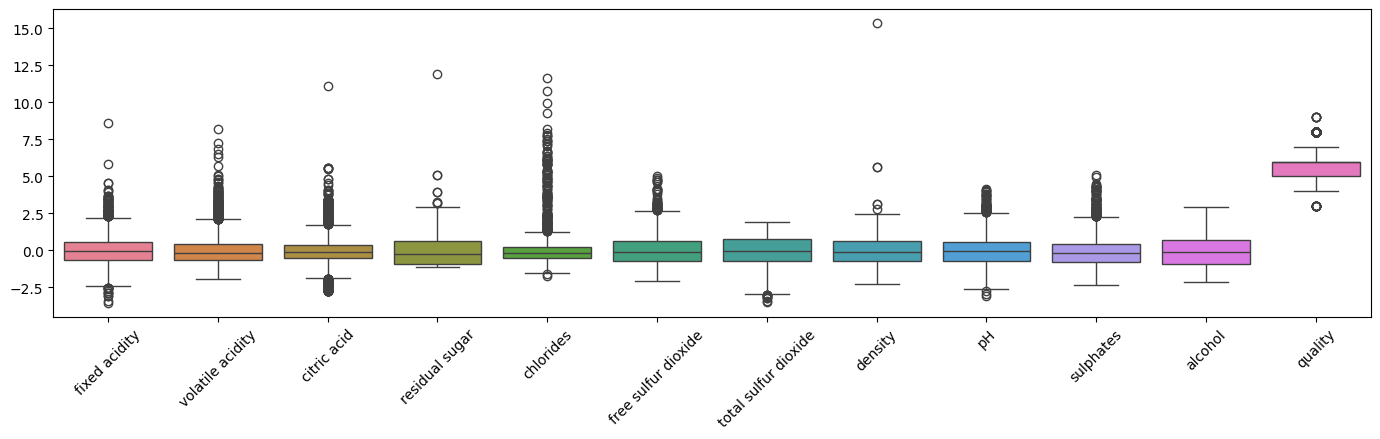

In [26]:
fig, ax = plt.subplots(1, figsize=(17,4))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

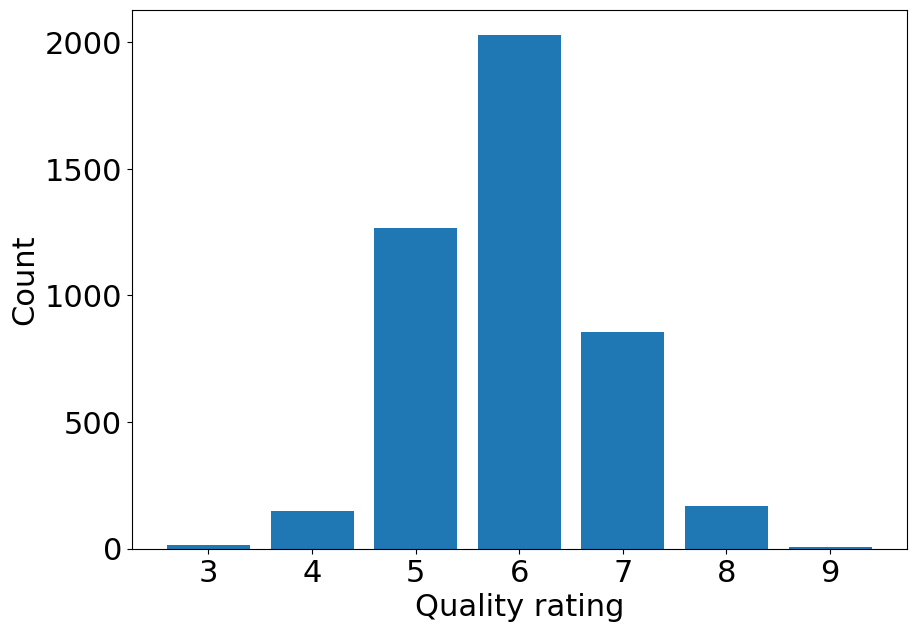

/tmp/ipykernel_23260/2852275716.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  data['boolQuality'][data['quality']>5] = 1


,quality,boolQuality
0,6,0
1,6,0
2,6,0
3,6,0
4,6,0
...,...,...
4893,6,0
4894,5,0
4895,6,0
4896,7,0


In [28]:
fig = plt.figure(figsize=(10,7))

counts = data['quality'].value_counts()
plt.bar(list(counts.keys()), counts)
plt.xlabel('Quality rating')
plt.ylabel('Count')
plt.show()

data['boolQuality'] = 0
data['boolQuality'][data['quality']>5] = 1
data[['quality', 'boolQuality']]

In [29]:
dataT = torch.tensor( data[cols2zscore].values ).float()
labels = torch.tensor( data['boolQuality'].values ).float()

print(dataT.shape)
print(labels.shape)

labels = labels[:,None]
print(labels.shape)

torch.Size([4489, 11])
torch.Size([4489])
torch.Size([4489, 1])


In [31]:
train_data, test_data, train_labels, test_labels = train_test_split(dataT, labels, test_size=.8)

train_data = TensorDataset(train_data, train_labels)
test_data = TensorDataset(test_data, test_labels)

batchsize = 64
train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])